In [2]:
from google.colab import files
uploaded = files.upload()

Saving students_dropout_academic_success.csv to students_dropout_academic_success.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

import joblib

ModuleNotFoundError: No module named 'catboost'

In [4]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


In [6]:
import pandas as pd

# Load the dataset into a DataFrame named 'df'
file_name = 'students_dropout_academic_success.csv'
try:
    df = pd.read_csv(file_name)
    print(f"Successfully loaded '{file_name}' into a DataFrame.\n")

    # Column names
    print("Column names:")
    print(df.columns.tolist())
    print("\n")

    # Dataset information
    print("Dataset information:")
    print(df.info())
    print("\n")

    # Missing values
    print("Missing values:")
    print(df.isnull().sum())
    print("\n")

    # Statistical summary
    print("Statistical summary:")
    print(df.describe())
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found. Please make sure it's uploaded and spelled correctly.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Successfully loaded 'students_dropout_academic_success.csv' into a DataFrame.

Column names:
['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem 

In [8]:
print('Duplicate Rows:', df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Rows: 0


In [9]:
# Check missing values
print(df.isnull().sum())

# Fill numeric missing values with median

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

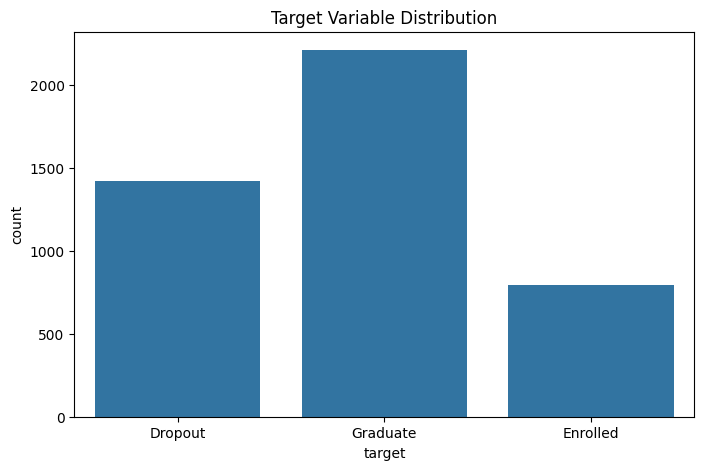

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x='target', data=df)
plt.title('Target Variable Distribution')
plt.show()

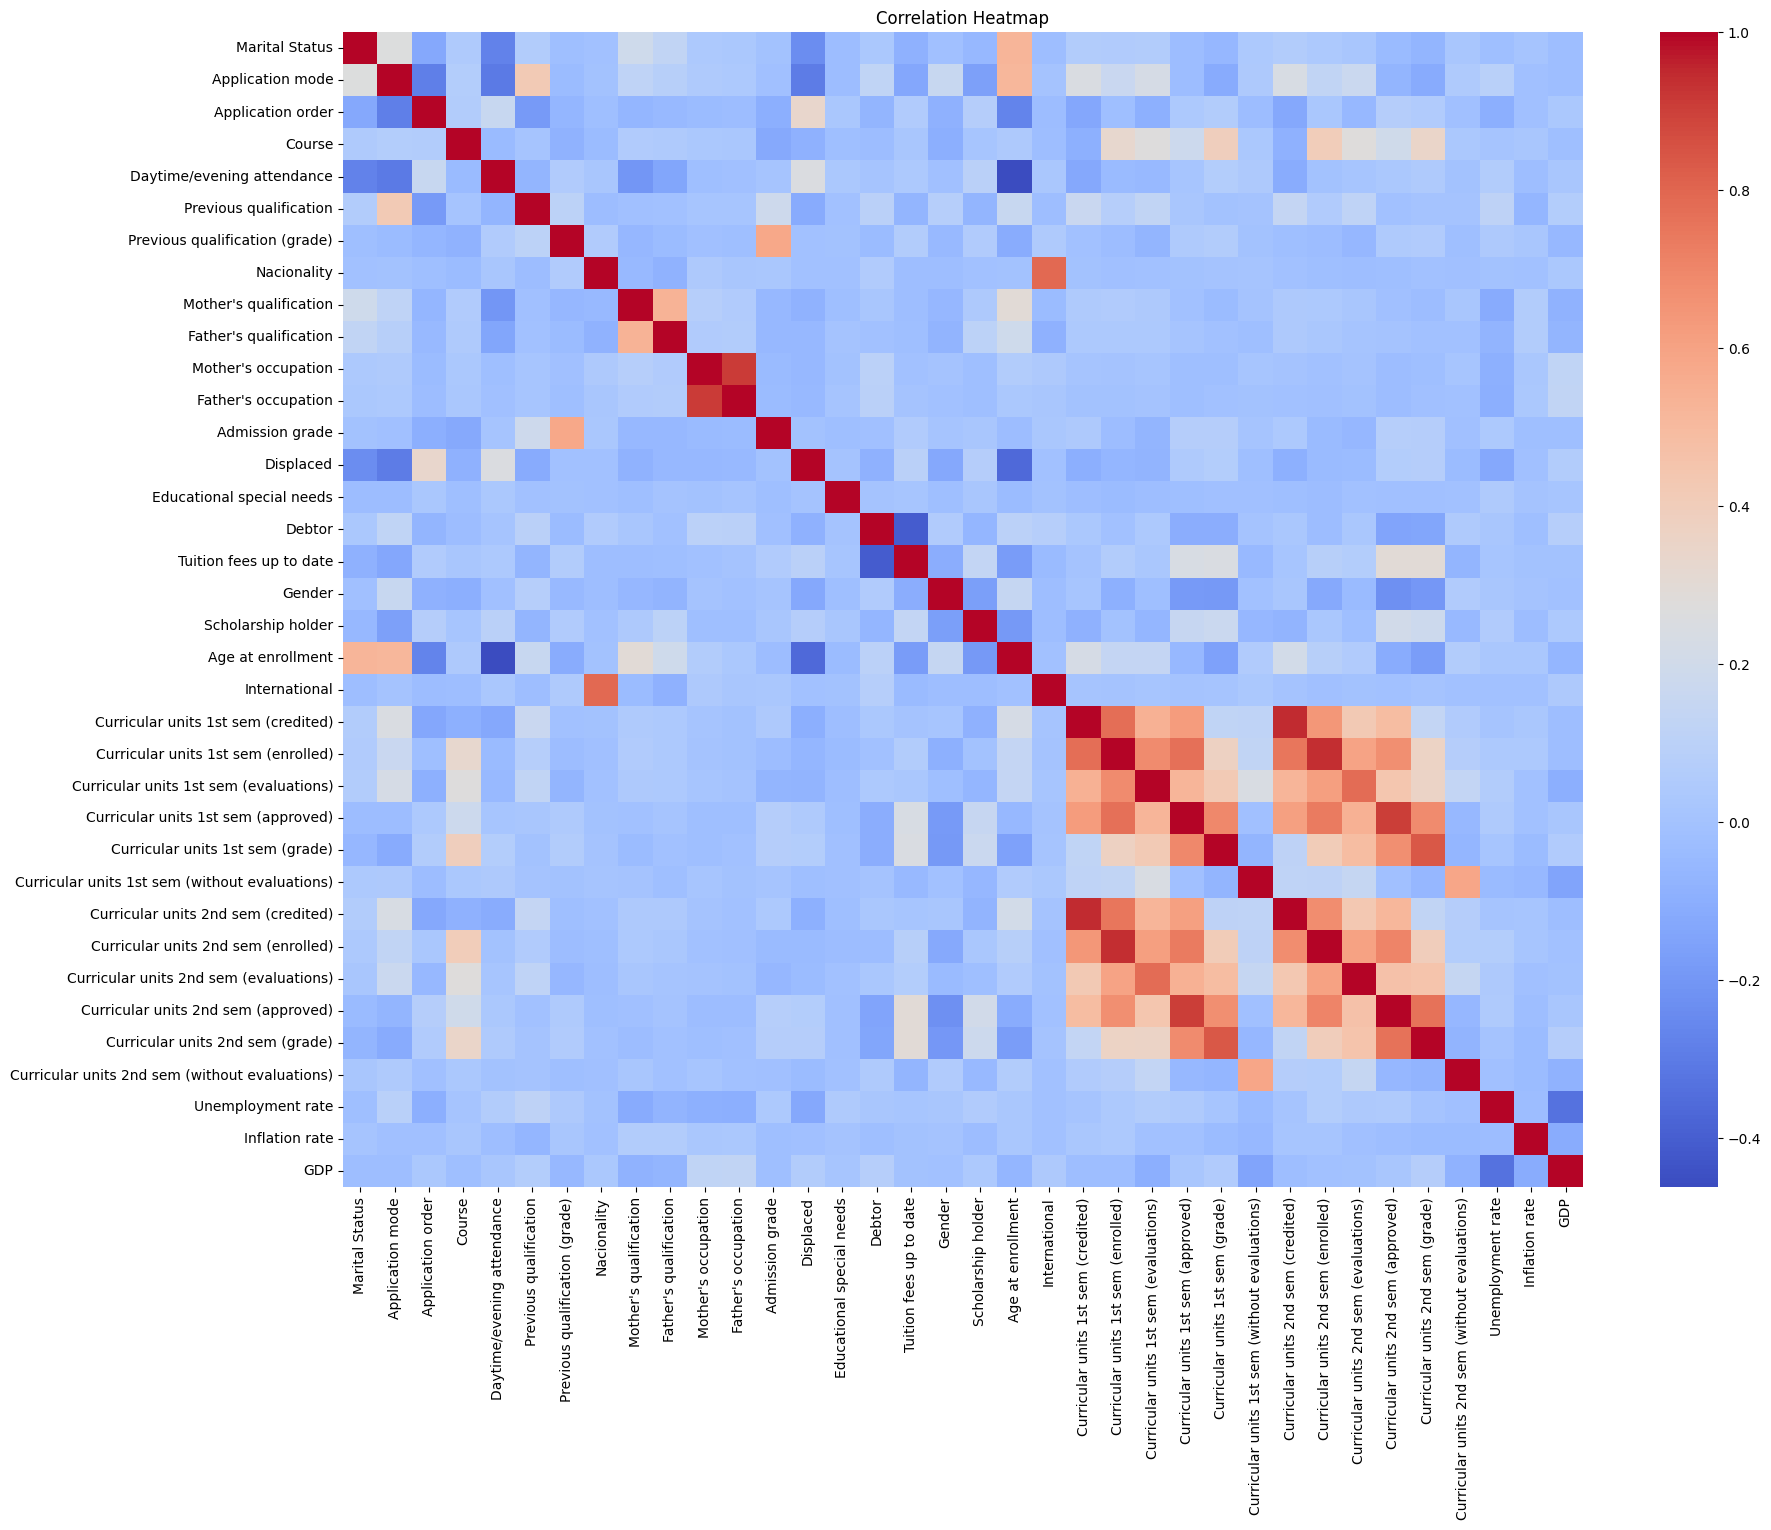

In [11]:
plt.figure(figsize=(20,15))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

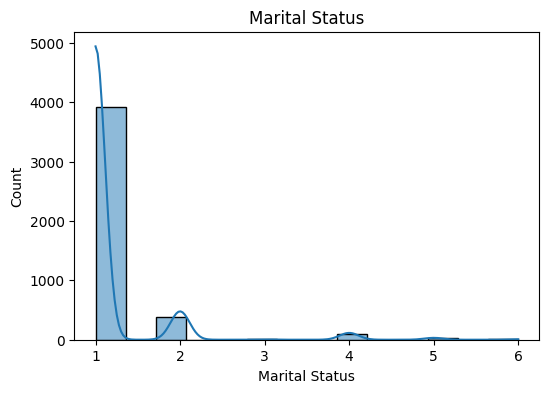

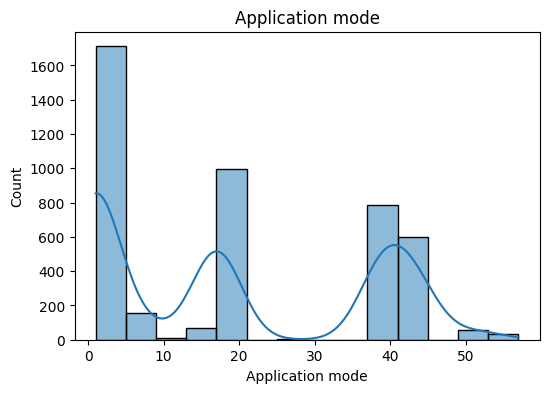

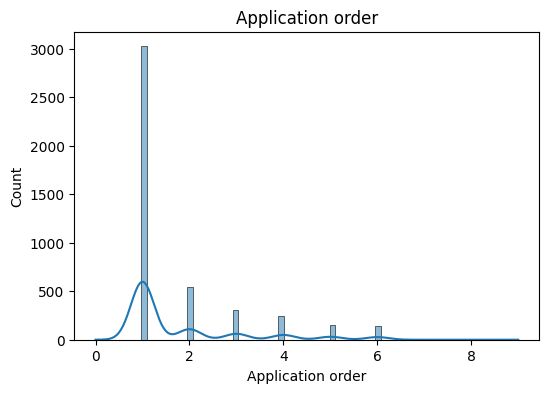

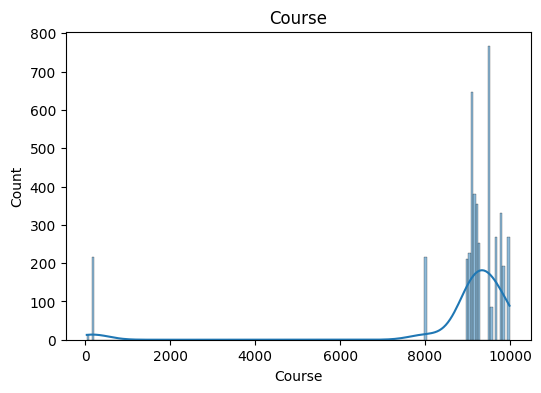

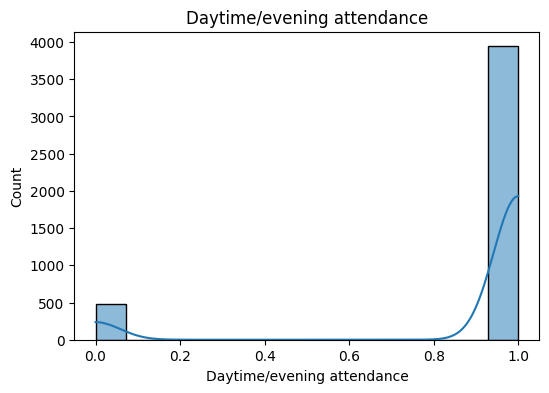

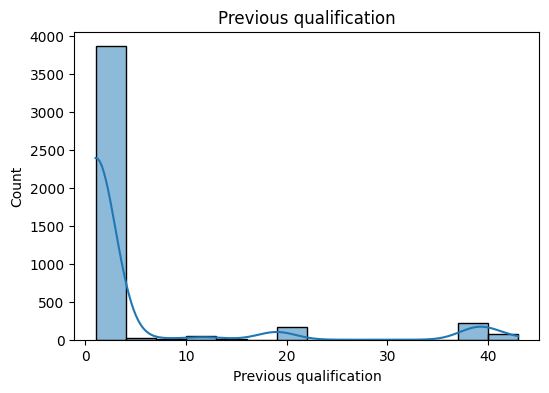

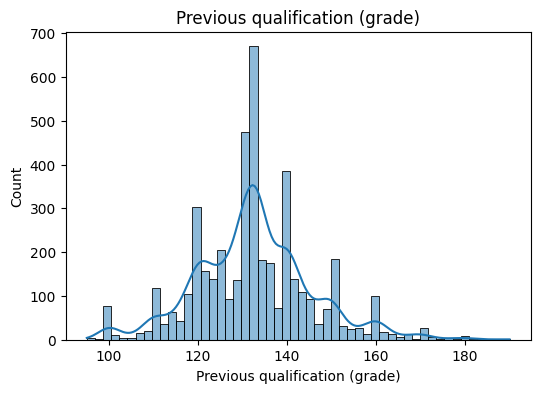

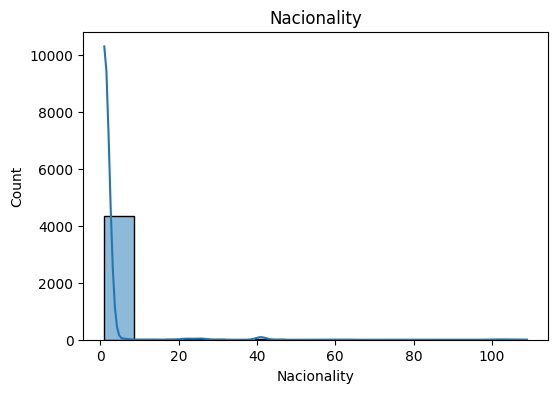

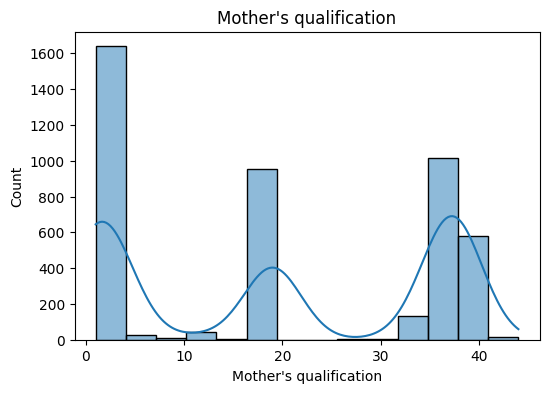

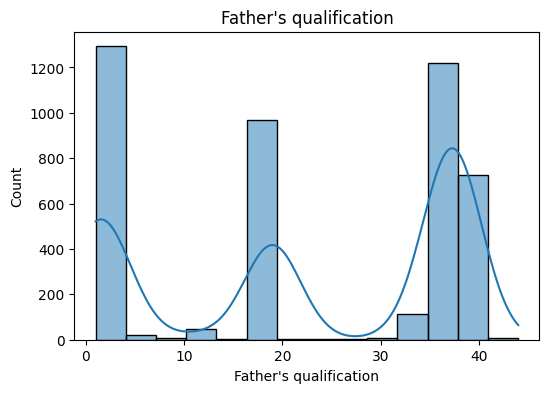

In [12]:
numeric_features = df.select_dtypes(include=np.number).columns

for col in numeric_features[:10]:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

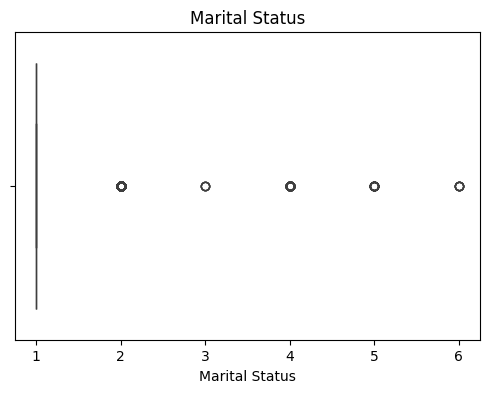

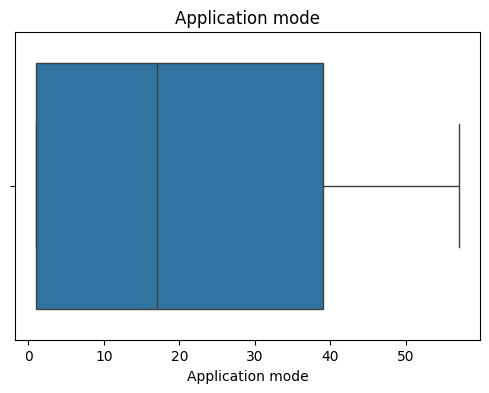

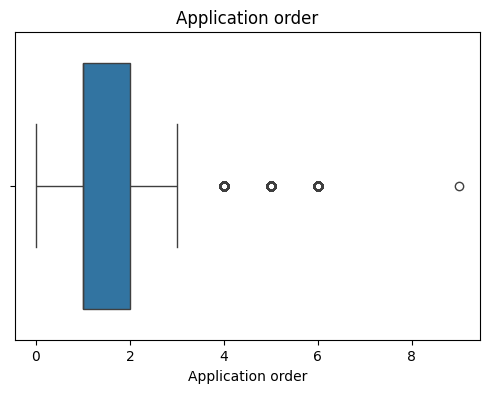

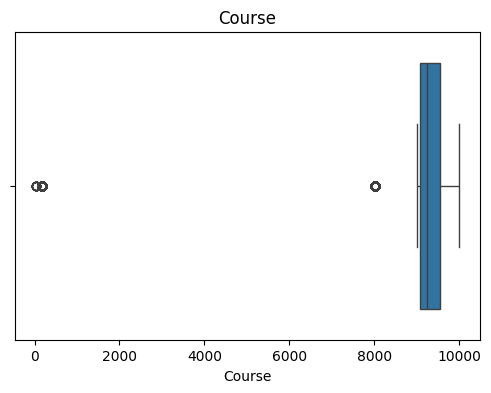

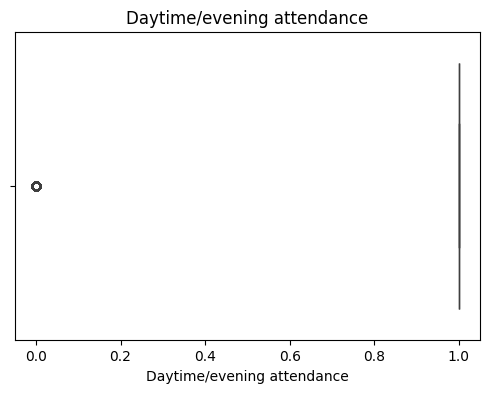

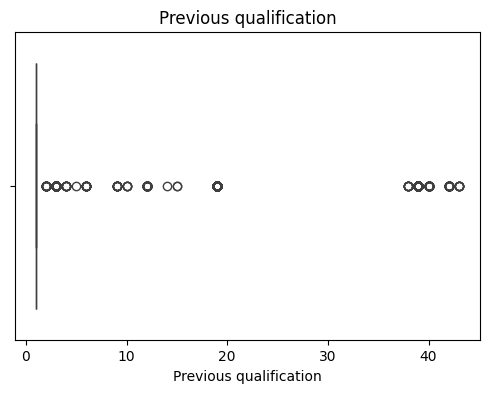

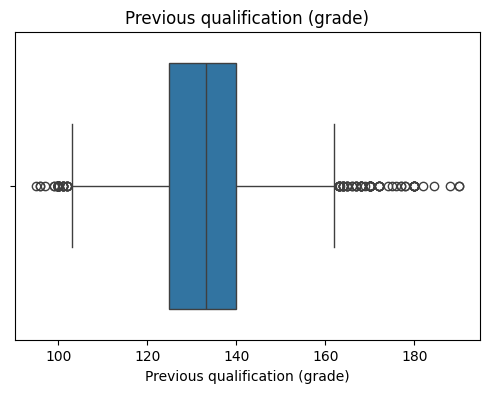

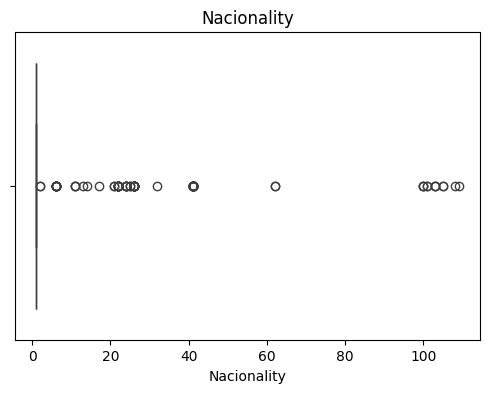

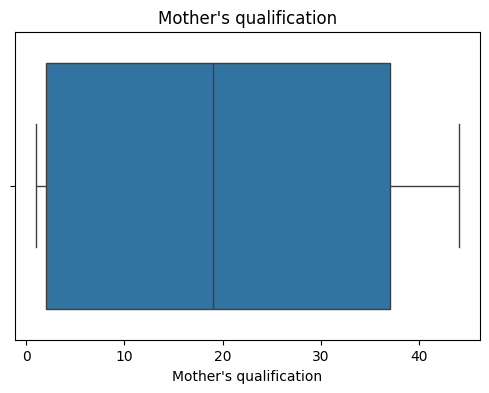

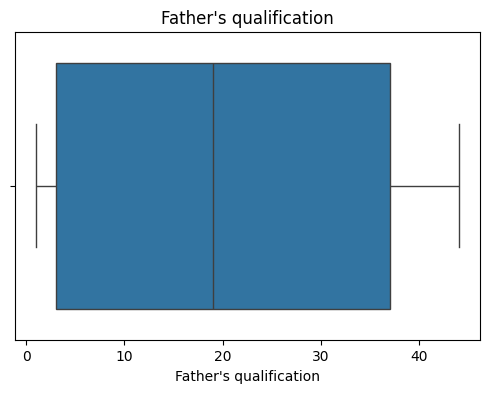

In [13]:
for col in numeric_features[:10]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

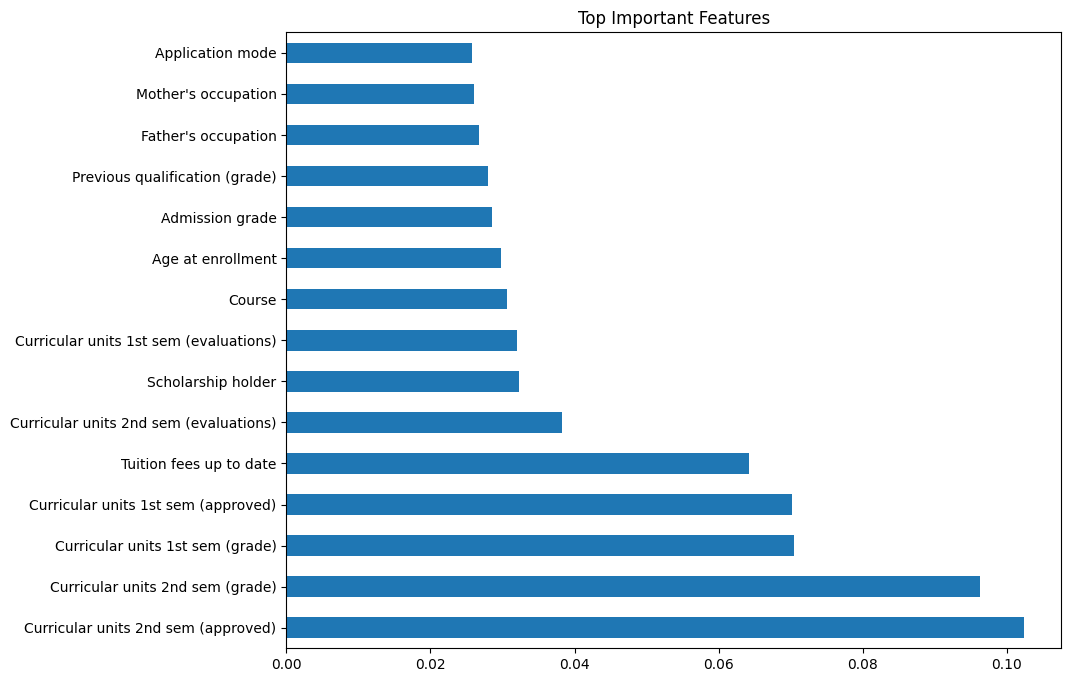

In [14]:
# Encode target temporarily
le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df['target'])

X_temp = df.drop(['target', 'target_encoded'], axis=1)
y_temp = df['target_encoded']

model = ExtraTreesClassifier()
model.fit(X_temp, y_temp)

importance = pd.Series(model.feature_importances_, index=X_temp.columns)

importance.nlargest(15).plot(kind='barh', figsize=(10,8))
plt.title('Top Important Features')
plt.show()

In [15]:
label_encoder = LabelEncoder()

df['target'] = label_encoder.fit_transform(df['target'])

print(label_encoder.classes_)

['Dropout' 'Enrolled' 'Graduate']


In [16]:
X = df.drop('target', axis=1)
y = df['target']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print('Before SMOTE:', y_train.value_counts())
print('After SMOTE:', pd.Series(y_train_resampled).value_counts())

Before SMOTE: target
2    1767
0    1137
1     635
Name: count, dtype: int64
After SMOTE: target
2    1767
0    1767
1    1767
Name: count, dtype: int64


In [22]:
from catboost import CatBoostClassifier

models = {
    'Random Forest': RandomForestClassifier(random_state=42),

    'Extra Trees': ExtraTreesClassifier(random_state=42),

    'Gradient Boosting': GradientBoostingClassifier(random_state=42),

    'XGBoost': XGBClassifier(
        eval_metric='mlogloss',
        random_state=42
    ),

    'LightGBM': LGBMClassifier(random_state=42),

    'CatBoost': CatBoostClassifier(
        verbose=0,
        random_state=42
    )
}

In [23]:
results = []

for name, model in models.items():

    print(f'\nTraining {name}...')

    model.fit(X_train_resampled, y_train_resampled)

    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, average='weighted')

    results.append([name, accuracy, f1])

    print('Accuracy:', accuracy)
    print('F1 Score:', f1)

    print(classification_report(y_test, predictions))


Training Random Forest...
Accuracy: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       284
           1       1.00      1.00      1.00       159
           2       1.00      1.00      1.00       442

    accuracy                           1.00       885
   macro avg       1.00      1.00      1.00       885
weighted avg       1.00      1.00      1.00       885


Training Extra Trees...
Accuracy: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       284
           1       1.00      1.00      1.00       159
           2       1.00      1.00      1.00       442

    accuracy                           1.00       885
   macro avg       1.00      1.00      1.00       885
weighted avg       1.00      1.00      1.00       885


Training Gradient Boosting...
Accuracy: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       284
           1       1.00      1.00      1.00       159
           2       1.00      1.00      1.00       442

    accuracy                           1.00       885
   macro avg       1.00      1.00      1.00       885
weighted avg       1.00      1.00      1.00       885



In [24]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'F1 Score']
)

print(results_df.sort_values(by='Accuracy', ascending=False))

               Model  Accuracy  F1 Score
0      Random Forest       1.0       1.0
1        Extra Trees       1.0       1.0
2  Gradient Boosting       1.0       1.0
3            XGBoost       1.0       1.0
4           LightGBM       1.0       1.0
5           CatBoost       1.0       1.0


In [25]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'F1 Score']
)

print(results_df.sort_values(by='Accuracy', ascending=False))

               Model  Accuracy  F1 Score
0      Random Forest       1.0       1.0
1        Extra Trees       1.0       1.0
2  Gradient Boosting       1.0       1.0
3            XGBoost       1.0       1.0
4           LightGBM       1.0       1.0
5           CatBoost       1.0       1.0


In [26]:
best_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function='MultiClass',
    verbose=0,
    random_state=42
)

best_model.fit(X_train_resampled, y_train_resampled)

predictions = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, predictions)

print('Final Accuracy:', accuracy)

print(classification_report(y_test, predictions))

Final Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       284
           1       1.00      1.00      1.00       159
           2       1.00      1.00      1.00       442

    accuracy                           1.00       885
   macro avg       1.00      1.00      1.00       885
weighted avg       1.00      1.00      1.00       885



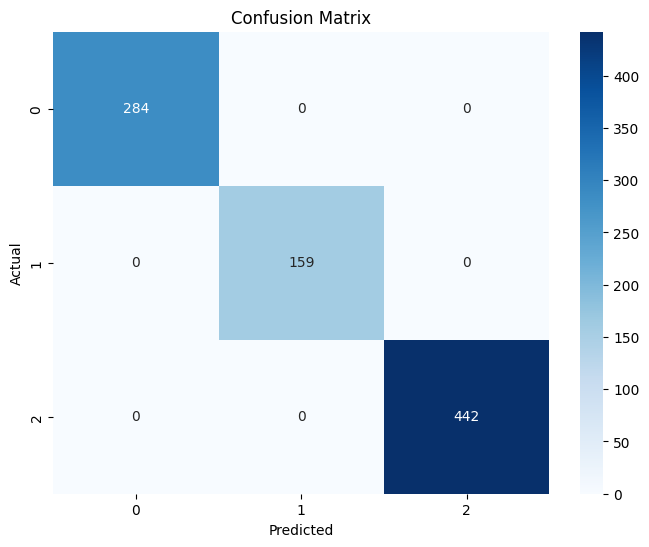

In [27]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [30]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(label_encoder, 'models/label_encoder.pkl')

print('Model Saved Successfully')

Model Saved Successfully


In [31]:
model = joblib.load('models/best_model.pkl')
scaler = joblib.load('models/scaler.pkl')
encoder = joblib.load('models/label_encoder.pkl')

### Loaded Model

The `model` variable now holds your trained `CatBoostClassifier`.

In [33]:
# You can inspect the loaded model, for example:
# print(model)
# To make predictions using the loaded model:
# sample_prediction = model.predict(X_test_scaled[0].reshape(1, -1))
# print(f"Prediction for first test sample: {sample_prediction}")

In [36]:
import joblib
import os

# Example of an object to save
example_object = {'data': [1, 2, 3], 'name': 'sample'}

# Define the directory and filename
save_directory = 'saved_objects'
file_path = os.path.join(save_directory, 'st.pkl')

# Create the directory if it doesn't exist
os.makedirs(save_directory, exist_ok=True)

# Save the object to a .pkl file
joblib.dump(example_object, file_path)

print(f"Object successfully saved to {file_path}")

Object successfully saved to saved_objects/st.pkl


In [37]:
import pickle

# save model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# download
from google.colab import files
files.download("model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>